In [1]:
import numpy as np

def f(x):
    return np.exp(-50 * (x - 0.5)**2)

def manual_dft(N):
    # 1. Sample the Gaussian function on [0, 1)
    n_idx = np.arange(N)
    x_val = n_idx / N
    xn = f(x_val)

    # 2. Create the DFT matrix (Equation 3)
    # k represents the frequency bins, n represents time/space bins
    k = n_idx.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n_idx / N)

    # 3. Compute Xk = W * xn
    Xk = np.dot(W, xn)
    return Xk

# Execute for required N values
for N in [32, 64, 128]:
    Xk = manual_dft(N)
    print(f"N={N} | X_0: {Xk[0].real:.4f} | X_1: {Xk[1].real:.4f} + {Xk[1].imag:.4f}i")

N=32 | X_0: 8.0212 | X_1: -6.5844 + -0.0000i
N=64 | X_0: 16.0424 | X_1: -13.1687 + -0.0000i
N=128 | X_0: 32.0848 | X_1: -26.3375 + -0.0000i


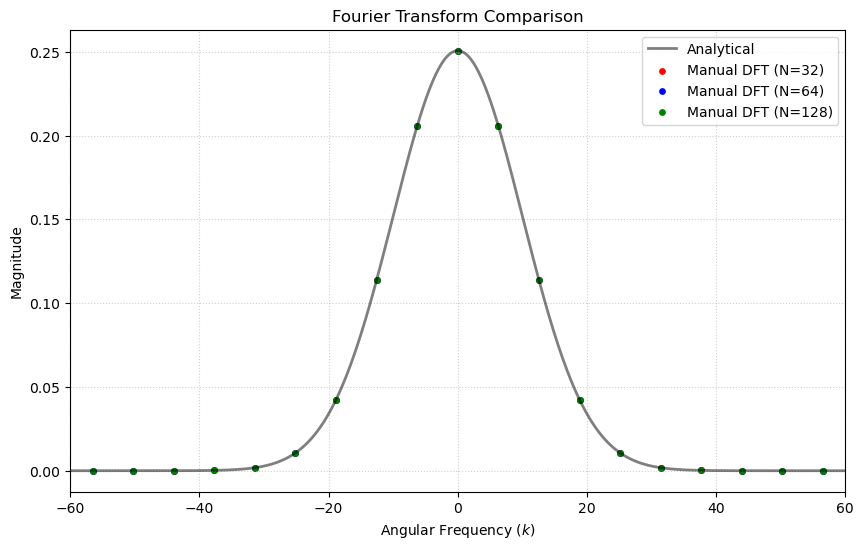

In [2]:
import matplotlib.pyplot as plt

def f(x):
    return np.exp(-50 * (x - 0.5)**2)

def analytical_mag(k):
    return np.sqrt(np.pi / 50) * np.exp(-k**2 / 200)

def manual_dft(N):
    n_idx = np.arange(N)
    x_val = n_idx / N
    xn = f(x_val)

    k_idx = n_idx.reshape((N, 1))
    W = np.exp(-2j * np.pi * k_idx * n_idx / N)
    Xk = np.dot(W, xn)

    # Manual Frequency & Shift Logic
    # Generate the integer frequency bins manually
    # Logic: [0, 1, ..., N/2, -N/2+1, ..., -1]
    k_bins = np.zeros(N)
    for i in range(N):
        if i <= N // 2:
            k_bins[i] = i
        else:
            k_bins[i] = i - N

    # Convert to angular frequency k (since L=1, delta_k = 2*pi)
    k_angular = 2 * np.pi * k_bins

    # Manually shift for plotting (moving negative frequencies to the left)
    shift_idx = np.argsort(k_angular)
    return k_angular[shift_idx], Xk[shift_idx]

# Plotting
plt.figure(figsize=(10, 6))

# Analytical curve
k_fine = np.linspace(-60, 60, 500)
plt.plot(k_fine, analytical_mag(k_fine), 'k-', lw=2, label='Analytical', alpha=0.5)

# Manual DFT results
colors = ['red', 'blue', 'green']
for N, color in zip([32, 64, 128], colors):
    k_plot, Xk_plot = manual_dft(N)

    # Normalize by 1/N to match the continuous Fourier Transform scale
    plt.scatter(k_plot, np.abs(Xk_plot)/N, color=color, s=15,
                label=f'Manual DFT (N={N})')

plt.title('Fourier Transform Comparison')
plt.xlabel('Angular Frequency ($k$)')
plt.ylabel('Magnitude')
plt.xlim(-60, 60)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()